In [194]:
from dotenv import load_dotenv
import os

In [195]:
load_dotenv("../.env") 
MONGO_URI = os.getenv("MONGO_URI")
print(MONGO_URI[:10] + "...") 

mongodb+sr...


In [196]:
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,[politique],neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,[autre],negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,[politique],neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,[politique],neutre,rss,2026-01-19 04:00:00,0.00000,fr


In [197]:
print("Total articles:", len(df))
print(df.info())
print(df.isna().sum())
lignes_vides = df[df.isin(["VIDE"]).any(axis=1)]
print("Nombre de lignes avec au moins un contenu vide :", len(lignes_vides))
lignes_vides

Total articles: 1668
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   _id               1668 non-null   object        
 1   id_article        1668 non-null   object        
 2   source            1668 non-null   object        
 3   titre             1668 non-null   object        
 4   date_publication  1668 non-null   datetime64[ns]
 5   contenu           1668 non-null   object        
 6   url               1668 non-null   object        
 7   categorie         1668 non-null   object        
 8   sentiment         1668 non-null   object        
 9   source_type       1668 non-null   object        
 10  created_at        1668 non-null   object        
 11  sentiment_score   1668 non-null   float64       
 12  langue            1668 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(11)
memory usage

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue


In [198]:
from collections import Counter
types = Counter()

for doc in collection.find({}, {"date_publication": 1}):
    value = doc.get("date_publication")
    types[type(value).__name__] += 1

print(types)

Counter({'datetime': 1668})


In [48]:
sample_dates = collection.find(
    {"date_publication": {"$type": "string"}},
    {"date_publication": 1}
).limit(20)

for doc in sample_dates:
    print(doc["date_publication"])

2026-02-22T09:52:50+00:00
2026-02-22T11:05:53+00:00
2026-02-23T03:00:00+00:00
2026-02-23T03:00:00+00:00
2026-02-23T03:00:00+00:00
2026-02-23T03:12:40+00:00
2026-02-23T04:30:08+00:00
2026-02-23T05:25:05+00:00
2026-02-23T05:31:00.001000+03:00
2026-02-23T05:32:00+03:00
2026-02-23T05:33:00+03:00
2026-02-23T05:33:00.001000+03:00
2026-02-23T05:35:00.002000+03:00
2026-02-23T05:35:00.004000+03:00
2026-02-23T05:35:00.006000+03:00
2026-02-23T05:35:00.007000+03:00
2026-02-23T05:35:00.008000+03:00
2026-02-23T05:35:00.017000+03:00
2026-02-23T05:35:00.019000+03:00
2026-02-23T05:37:17+00:00


In [8]:
from dateutil import parser

invalid_docs = []

for doc in collection.find({"date_publication": {"$type": "string"}}):
    try:
        parser.parse(doc["date_publication"])
    except:
        invalid_docs.append(doc["_id"])

print("Dates invalides :", len(invalid_docs))


Dates invalides : 0


In [49]:
sample_dates = collection.find(
    {"date_publication": {"$type": "date"}},
    {"date_publication": 1}
).limit(20)

for doc in sample_dates:
    print(doc["date_publication"])

2002-02-26 15:34:11
2002-02-26 15:34:11
2002-04-10 16:37:03
2002-04-10 16:37:03
2004-07-07 12:14:04
2004-07-07 12:14:04
2004-12-28 10:07:07
2004-12-28 10:07:07
2005-03-02 19:37:08
2005-03-02 19:37:08
2005-05-24 01:00:00
2005-05-24 01:00:00
2008-12-17 14:07:35
2009-01-26 18:47:54
2009-01-26 18:47:54
2009-02-09 16:07:14
2009-02-09 16:07:14
2009-03-13 11:43:22
2009-03-13 11:43:22
2009-04-23 17:54:19


In [50]:
from dateutil import parser
from datetime import datetime

for doc in collection.find({"date_publication": {"$type": "string"}}):
    try:
        new_date = parser.parse(doc["date_publication"])
        
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {"date_publication": new_date}}
        )
    except Exception as e:
        print(f"Erreur sur {doc['_id']} : {doc['date_publication']}")


In [51]:
from datetime import datetime

def normalize_date(date_str):
    if not date_str:
        return None
    
    cleaned = date_str.replace("Date:", "").strip()
    
    try:
        return datetime.strptime(cleaned, "%d/%m/%Y")
    except:
        return None


for doc in collection.find():
    
    date_pub = doc.get("date_publication")
    created = doc.get("created_at")
    
    new_date = None
    
    # 1️⃣ Si déjà datetime
    if isinstance(date_pub, datetime):
        continue
    
    # 2️⃣ Si string → essayer conversion
    if isinstance(date_pub, str):
        new_date = normalize_date(date_pub)
    
    # 3️⃣ Si vide ou conversion échoue → fallback created_at
    if not new_date:
        if isinstance(created, datetime):
            new_date = created
    
    # 4️⃣ Update si on a trouvé une date
    if new_date:
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {"date_publication": new_date}}
        )
    else:
        print(f"Aucune date valide pour {doc['_id']}")


In [52]:
doc = collection.find_one({"_id": "696f91b6c613d99e9417630f"})
print(doc)


None


In [14]:
from bson import ObjectId

doc = collection.find_one({"_id": ObjectId("696f91b6c613d99e9417630f")})
print(doc)


{'_id': ObjectId('696f91b6c613d99e9417630f'), 'id_article': 'https://www.malagasynews.com/actualites/diplomatie-sa-majeste-le-roi-repond-favorablement-a-linvitation-du-president-donald-j-trump-pour-devenir-membre-fondateur-du-conseil-de-paix-mae/', 'source': 'Malagasy News', 'titre': 'Diplomatie: Sa Majesté le Roi répond favorablement à l’invitation du Président Donald J Trump pour devenir Membre Fondateur du Conseil de Paix (MAE)', 'date_publication': None, 'contenu': 'La participation à ce Conseil est réservée à un groupe restreint de leaders de stature internationale, engagés en faveur d’un avenir sûr et prospère pour les générations futures, précise le communiqué, ajoutant que cette invitation constitue une reconnaissance du leadership éclairé de Sa Majesté le Roi, et de Sa Stature en tant qu’acteur de paix incontournable. Elle témoigne de la confiance dont jouit le Souverain auprès du Président des États-Unis et de la communauté internationale. Tout en saluant l’engagement et la v

In [15]:
from bson import ObjectId

for doc in collection.find({
    "date_publication": None
}):
    
    object_date = doc["_id"].generation_time
    
    collection.update_one(
        {"_id": doc["_id"]},
        {"$set": {"date_publication": object_date}}
    )


In [17]:
collection.aggregate([
    {"$group": {"_id": {"$type": "$date_publication"}, "count": {"$sum": 1}}}
])


In [62]:
result = collection.aggregate([
    {"$group": {"_id": {"$type": "$date_publication"}, "count": {"$sum": 1}}}
])

for r in result:
    print(r)


{'_id': 'date', 'count': 1668}


In [63]:
doc = collection.find_one(
    {"date_publication": {"$type": "string"}},
    {"date_publication": 1}
)

print(doc)


None


In [54]:
from bson import ObjectId

doc_id = ObjectId("698b52fce2237c9990fbc2ef")

collection.update_one(
    {"_id": doc_id},
    {"$set": {"date_publication": doc_id.generation_time}}
)


UpdateResult({'n': 0, 'electionId': ObjectId('7fffffff000000000000003c'), 'opTime': {'ts': Timestamp(1771843235, 2), 't': 60}, 'nModified': 0, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1771843235, 2), 'signature': {'hash': b'f8f\xbb@^\x99C+\xfdY\\\xa3l\xb8]\xe6\xb4\xc1=', 'keyId': 7573748671250956292}}, 'operationTime': Timestamp(1771843235, 2), 'updatedExisting': False}, acknowledged=True)

In [64]:
result = collection.aggregate([
    {"$group": {"_id": {"$type": "$date_publication"}, "count": {"$sum": 1}}}
])

for r in result:
    print(r)


{'_id': 'date', 'count': 1668}


In [22]:
collection.create_index("date_publication")


'date_publication_1'

In [23]:
collection.index_information()


{'_id_': {'v': 2, 'key': [('_id', 1)]},
 'date_publication_1': {'v': 2, 'key': [('date_publication', 1)]}}

In [134]:
import pandas as pd
from openpyxl import Workbook
from bson import ObjectId

# 🔹 Récupérer toutes les données
docs = list(collection.find())

# 🔹 Convertir ObjectId en string et gérer les listes
for d in docs:
    d["_id"] = str(d["_id"])
    for key, value in d.items():
        # Si la valeur est une liste, la convertir en chaîne séparée par ", "
        if isinstance(value, list):
            d[key] = ", ".join(str(v) for v in value)

# 🔹 Convertir en DataFrame
df = pd.DataFrame(docs)

# =========================
# 1️⃣ Export CSV
# =========================
csv_path = "export_verification.csv"
df.to_csv(csv_path, index=False)
print("CSV exporté :", csv_path)

# =========================
# 2️⃣ Export Excel
# =========================
xlsx_path = "export_verification.xlsx"

wb = Workbook()
ws = wb.active
ws.title = "Mongo_Export"

# Header
ws.append(list(df.columns))

# Lignes
for row in df.itertuples(index=False):
    ws.append(list(row))

wb.save(xlsx_path)
print("Excel exporté :", xlsx_path)


CSV exporté : export_verification.csv
Excel exporté : export_verification.xlsx


In [25]:
collection.delete_many({
    "$or": [
        {"contenu": ""},
        {"contenu": None},
        {"contenu": {"$regex": r"^\s*$"}}
    ]
})


DeleteResult({'n': 101, 'electionId': ObjectId('7fffffff000000000000003c'), 'opTime': {'ts': Timestamp(1771422537, 11), 't': 60}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1771422537, 11), 'signature': {'hash': b'\xe3\xb1\x06\x8b\xdb\x85\xad\x95\x0b\x8e\x00\xa1Z\xb3\x9a\xc1\x88\xa3\xe3\x15', 'keyId': 7573748671250956292}}, 'operationTime': Timestamp(1771422537, 11)}, acknowledged=True)

In [57]:
from pymongo import UpdateOne

# Listes de référence
RSS_FEEDS = [
    "https://www.madagascar-tribune.com/spip.php?page=backend",
    "https://www.lexpress.mg/feeds/posts/default",
    "https://newsmada.com/feed/",
    "https://midi-madagasikara.mg/feed/",  
    "https://2424.mg/feed/",
    "https://rsf.org/fr/rss/afrique/madagascar/feed.xml",
    "https://www.madagate.org/index.php?format=feed&type=rss",
    "https://lgdi-madagascar.com/feed/",
    "https://midi-madagasikara.mg/category/politique/feed/",
    "https://midi-madagasikara.mg/category/economie/feed/",
    "https://www.lexpress.mg/feeds/posts/default/-/Politique",
    "https://www.lexpress.mg/feeds/posts/default/-/%C3%89conomie",
    "https://newsmada.com/category/les-nouvelles/feed/",
    "https://newsmada.com/category/les-nouvelles/politique/feed/",
    "https://2424.mg/category/actualite/politique/feed/",
    "https://2424.mg/category/actualite/economie/feed/",
    "https://www.lemonde.fr/madagascar/rss_full.xml",
    "https://www.courrierinternational.com/feed/rubrique/madagascar/rss.xml",
    "https://news.google.com/rss/search?q=Madagascar&hl=fr&gl=FR&ceid=FR:fr",
    "https://tanikomadagascar.com/feed/",
    "https://namana-studio.fr/feed/",
    "https://www.youtube.com/feeds/videos.xml?channel_id=UCK84qSI2bEMWkX9vUptkAlA"
]

SCRAP_HTML_SOURCES = ["Malagasy News"]
SCRAP_SELENIUM_SOURCES = ["Orange Actu"]

operations = []

# Parcourir uniquement les docs où source_type est vide ou None
for doc in collection.find({"$or": [{"source_type": {"$exists": False}}, {"source_type": None}, {"source_type": ""}]}):
    source = (doc.get("source") or "").strip()
    source_type = None

    # Vérifier RSS
    if any(source.startswith(rss) for rss in RSS_FEEDS):
        source_type = "rss"
    # Vérifier SCRAP_HTML
    elif any(source.startswith(scrap) for scrap in SCRAP_HTML_SOURCES):
        source_type = "scrap_html"
    # Vérifier SCRAP_SELENIUM
    elif any(scrap in source for scrap in SCRAP_SELENIUM_SOURCES):
        source_type = "scrap_selenium"
    # fallback
    else:
        source_type = "inconnu"

    operations.append(
        UpdateOne(
            {"_id": doc["_id"]},
            {"$set": {"source_type": source_type}}
        )
    )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec source_type : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")



Aucun document vide à mettre à jour


In [65]:
result = collection.aggregate([
    {"$group": {"_id": "$source_type", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': 'scrap_html', 'count': 24}
{'_id': 'rss', 'count': 1576}
{'_id': 'scrap_selenium', 'count': 68}


In [44]:
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,"[politique, éducation, technologie]",neutre,rss,2026-01-20 05:36:32,0.0000
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],neutre,rss,2026-01-20 05:31:21,-0.0125
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,"[politique, technologie, culture]",negatif,rss,2026-01-19 05:35:00,-0.4000
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,"[politique, technologie, culture]",positif,rss,2026-01-19 05:00:00,0.2000
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,"[politique, culture]",neutre,rss,2026-01-19 04:00:00,0.0000


In [14]:
from pymongo import UpdateOne

operations = []

# Parcourir uniquement les documents où created_at est vide ou None
for doc in collection.find({"$or": [{"created_at": {"$exists": False}}, {"created_at": None}, {"created_at": ""}]}):
    date_pub = doc.get("date_publication")
    
    if date_pub:  # on ne copie que si date_publication existe
        operations.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {"$set": {"created_at": date_pub}}
            )
        )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec created_at : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")


Aucun document vide à mettre à jour


In [40]:
result = collection.aggregate([
     {"$group": {"_id": "$created_at", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': '2026-02-11T12:37:25.137031', 'count': 1}
{'_id': datetime.datetime(2026, 1, 12, 6, 40, 50), 'count': 1}
{'_id': datetime.datetime(2026, 1, 16, 6, 32, 53), 'count': 1}
{'_id': datetime.datetime(2026, 1, 6, 13, 54, 58), 'count': 1}
{'_id': '2026-02-10T14:24:10.067032', 'count': 1}
{'_id': datetime.datetime(2026, 1, 3, 8, 0), 'count': 3}
{'_id': '2026-02-10T14:06:10.468266', 'count': 1}
{'_id': '2026-02-13T08:43:34.006679', 'count': 1}
{'_id': '2026-02-16T15:12:52.611951', 'count': 1}
{'_id': '2026-02-17T08:35:33.615506', 'count': 1}
{'_id': '2026-02-11T12:38:26.611486', 'count': 1}
{'_id': '2026-02-10T16:02:10.274977+00:00', 'count': 1}
{'_id': '2026-02-18T09:57:53.909447', 'count': 1}
{'_id': '2026-02-10T16:02:06.098916+00:00', 'count': 1}
{'_id': '2026-02-18T09:57:44.607876', 'count': 1}
{'_id': datetime.datetime(2026, 1, 21, 4, 40), 'count': 1}
{'_id': datetime.datetime(2026, 1, 17, 13, 3, 20), 'count': 1}
{'_id': '2026-02-12T16:31:14.555231', 'count': 1}
{'_id': datetime.dat

In [16]:
# Vérifier le nombre de documents par sentiment_score
result = collection.aggregate([
    {"$group": {"_id": "$sentiment_score", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
])

for r in result:
    print(r)


{'_id': 0.0, 'count': 1739}
{'_id': 0.1, 'count': 47}
{'_id': 0.2, 'count': 46}
{'_id': 0.5, 'count': 35}
{'_id': 0.4, 'count': 22}
{'_id': 0.16666666666666666, 'count': 15}
{'_id': 0.375, 'count': 13}
{'_id': 0.25, 'count': 11}
{'_id': 0.05, 'count': 11}
{'_id': -0.0125, 'count': 11}
{'_id': -0.9, 'count': 11}
{'_id': -0.8, 'count': 10}
{'_id': 0.21428571428571427, 'count': 10}
{'_id': 0.3, 'count': 8}
{'_id': -0.05, 'count': 8}
{'_id': -0.4, 'count': 7}
{'_id': 0.125, 'count': 7}
{'_id': 0.15, 'count': 6}
{'_id': 0.10714285714285714, 'count': 6}
{'_id': -0.5, 'count': 6}
{'_id': -0.06666666666666667, 'count': 6}
{'_id': 0.03333333333333333, 'count': 6}
{'_id': -0.13333333333333333, 'count': 6}
{'_id': -0.00625, 'count': 6}
{'_id': 0.13333333333333333, 'count': 6}
{'_id': 0.016666666666666666, 'count': 5}
{'_id': 0.06666666666666667, 'count': 5}
{'_id': 0.225, 'count': 4}
{'_id': -0.025, 'count': 4}
{'_id': -0.125, 'count': 4}
{'_id': 0.0625, 'count': 4}
{'_id': 0.1875, 'count': 4}
{'

In [17]:
print(df["date_publication"].dtype)
df["date_publication"].head()

object


0    2026-01-20 05:36:32
1    2026-01-20 05:31:21
2    2026-01-19 05:35:00
3    2026-01-19 05:00:00
4    2026-01-19 04:00:00
Name: date_publication, dtype: object

In [66]:
import pandas as pd

df["date_publication"] = pd.to_datetime(
    df["date_publication"],
    errors="coerce"
)

print(df["date_publication"].dtype)
print("NaT :", df["date_publication"].isna().sum())

datetime64[ns]
NaT : 0


In [67]:
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce", utc=True)
print(df["date_publication"].dtype)

datetime64[ns, UTC]


In [200]:
df_filtre = df[df["date_publication"].dt.year.isin([2025, 2026])]
volume_jour = df_filtre.groupby(df_filtre["date_publication"].dt.date).size()

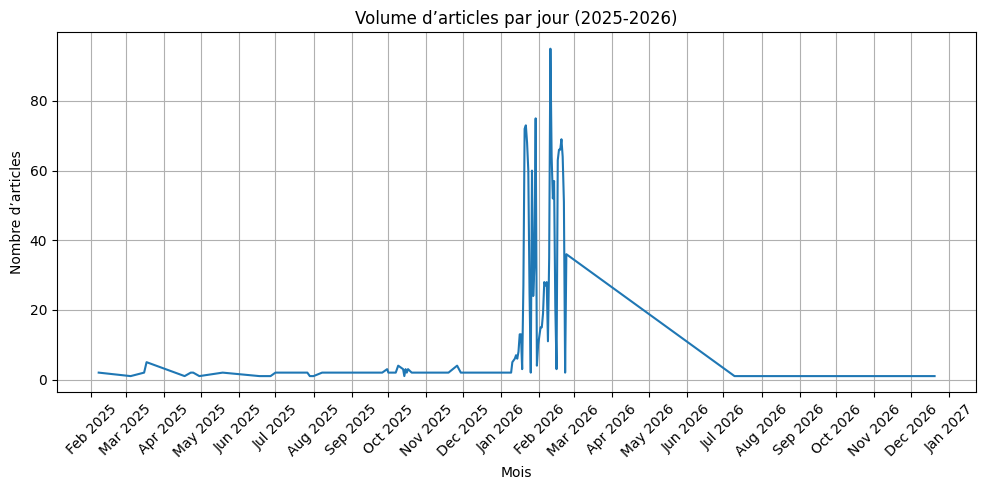

In [201]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10,5))

plt.plot(volume_jour.index, volume_jour.values)

# Affichage uniquement des mois
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Volume d’articles par jour (2025-2026)")
plt.xlabel("Mois")
plt.ylabel("Nombre d’articles")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

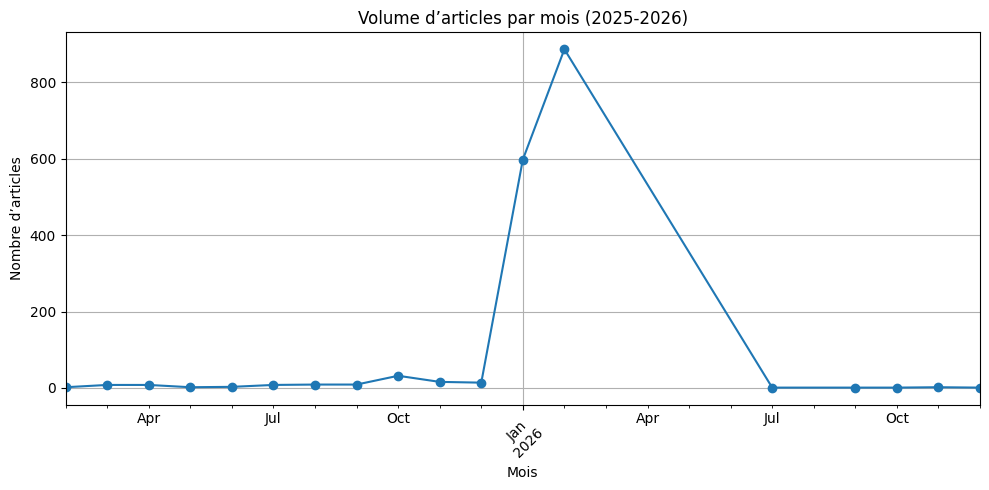

In [202]:
volume_mois = df_filtre.groupby(
    df_filtre["date_publication"].dt.to_period("M")
).size()

plt.figure(figsize=(10,5))
volume_mois.plot(marker='o')

plt.title("Volume d’articles par mois (2025-2026)")
plt.xlabel("Mois")
plt.ylabel("Nombre d’articles")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [207]:
df["categorie"] = df["categorie"].str.split(",")

In [216]:
df["categorie"].head()


0    [politique]
1    [politique]
2        [autre]
3    [politique]
4    [politique]
Name: categorie, dtype: object

In [212]:
df_exploded.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,politique,neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,politique,neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,autre,negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,politique,neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,politique,neutre,rss,2026-01-19 04:00:00,0.00000,fr


In [213]:
df_exploded["categorie"].head()

0    politique
1    politique
2        autre
3    politique
4    politique
Name: categorie, dtype: object

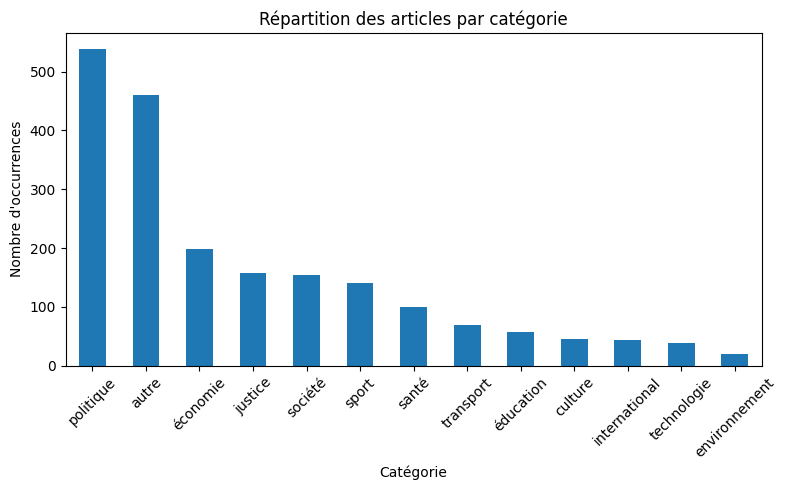

In [133]:
import matplotlib.pyplot as plt

volume_cat = df_exploded["categorie"].value_counts()

plt.figure(figsize=(8,5))
volume_cat.plot(kind="bar")

plt.title("Répartition des articles par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
count = collection.count_documents({
    "source": "https://tanikomadagascar.com/feed/"
})

print("Nombre d'articles à supprimer :", count)

Nombre d'articles à supprimer : 68


In [29]:
result = collection.delete_many({
     "source": "https://tanikomadagascar.com/feed/"
})

print("Nombre d'articles supprimés :", result.deleted_count)

Nombre d'articles supprimés : 68


In [30]:
result = collection.delete_many({
     "source": "https://tanikomadagascar.com/feed/"
})

print("Nombre d'articles supprimés :", result.deleted_count)

Nombre d'articles supprimés : 0


In [128]:
import re
import unicodedata
from bs4 import BeautifulSoup
from textblob import TextBlob
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

malagasy_words = {
    # ===== PRONOMS & MOTS COURANTS =====
    "izy", "anao", "aho", "isika", "ianao", "izy ireo", "izany", "ity", "ireo",
    "eto", "any", "amin", "amin'ny", "ao", "ary", "na", "fa", "raha", "satria",

    # ===== SOCIETE / ADMINISTRATION =====
    "firenena", "tanora", "mponina", "sekoly", "mpianatra",
    "governemanta", "ministera", "ben'ny tanàna", "ben ny tanana",
    "depiote", "depute", "filoha", "antoko politika",
    "lalàm-panorenana", "lalampanorenana",
    "repoblika", "kaominina", "prefe", "distrika",
    "mpitondra", "fitondrana", "biraom-panjakana",

    # ===== VIE QUOTIDIENNE =====
    "trano", "làlana", "lalana", "fianakaviana",
    "asa", "vidim-piainana", "vidimpiainana",
    "fampandrosoana", "fiainana", "vahoaka",
    "zaza", "reny", "ray",

    # ===== ECONOMIE / COMMERCE =====
    "toekarena", "varotra", "orinasa", "tsena",
    "banky", "fampiasam-bola", "fampiasambola",
    "hetra", "karama", "vola", "tetibola",
    "fividianana", "fanondranana", "fanondranana entana",

    # ===== SANTE =====
    "fahasalamana", "hopitaly", "hôpitaly",
    "dokoterà", "dokotera", "aretina",
    "vaksiny", "fanafody", "marary",
    "valanaretina", "hopital",

    # ===== EDUCATION =====
    "fanabeazana", "oniversite", "universite",
    "mpampianatra", "kilasy", "sekoly ambony",
    "mpianatra", "fampianarana",

    # ===== SPORT =====
    "baolina kitra", "lalao", "ekipa",
    "fifaninanana", "mpilalao", "stadiona",

    # ===== TECHNOLOGIE =====
    "haitao", "siansa", "fikajiana",
    "rindranasa", "aterineto", "tambajotra",
    "finday", "solosaina",

    # ===== ENVIRONNEMENT =====
    "tontolo iainana", "toetrandro",
    "fandotoana", "ala", "rano",
    "rivodoza", "hain-tany",

    # ===== INTERNATIONAL =====
    "iraisam-pirenena", "ady",
    "fifandraisana iraisam-pirenena",
    "firaisankina", "diplomasia",

    # ===== JUSTICE =====
    "heloka", "fitsarana",
    "mpisolovava", "polisy",
    "fonja", "lalàna", "lalana",

    # ===== TRANSPORT =====
    "fitaterana", "seranam-piaramanidina",
    "taxi-be", "taxibe",
    "bus", "fiara", "sambo",

    # ===== MEDIAS / ACTUALITE =====
    "vaovao", "gazety", "fampitam-baovao",
    "mpanao gazety", "tatitra",
    "fanambarana", "lahateny"
}

# =====================================================
# NORMALISATION
# =====================================================

def normalize_text(text: str) -> str:
    if not text:
        return ""

    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text(separator=" ")

    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")

    text = re.sub(r"[^\w\s]", " ", text)
    text = " ".join(text.split())

    return text

    
# =====================================================
# DETECTION LANGUE
# =====================================================

def detect_language(text: str, min_mg_words: int = 3) -> str:
    try:
        clean = normalize_text(text)
        words = clean.split()

        mg_count = sum(1 for w in words if w in malagasy_words)
        mg_ratio = mg_count / max(len(words), 1)

        # Override seulement si vrai signal MG
        if mg_count >= min_mg_words or mg_ratio > 0.25:
            return "mg"

        lang = detect(text)

        if lang in ["fr", "mg"]:
            return lang
        return "other"

    except:
        return "unknown"

# =====================================================
# SENTIMENT
# =====================================================

def analyze_sentiment(text: str) -> str:
    if not text:
        return "neutre"

    lang = detect_language(text)

    if lang == "fr":
        score = TextBlob(text).sentiment.polarity
    else:
        score = 0

    if score > 0.2:
        return "positif"
    elif score < -0.2:
        return "negatif"
    else:
        return "neutre"


def analyze_sentiment_score(text: str) -> float:
    lang = detect_language(text)
    if lang == "fr":
        return TextBlob(text).sentiment.polarity
    return 0.0

# =====================================================
# KEYWORDS MAP
# =====================================================

keywords_map = {

    "politique": [
        # FR fort
        "président", "premier ministre", "gouvernement", "député",
        "sénat", "assemblée nationale", "élection", "campagne",
        "parti", "opposition", "majorité", "constitution",
        "république", "mandat", "candidat", "ministre",
        "manifestation", "coup d etat",

        # MG fort
        "filoha", "governemanta", "ministera", "depiote",
        "fifidianana", "antoko politika", "lalampanorenana",
        "repoblika"
    ],

    "justice": [
        "tribunal", "juge", "procureur", "cour",
        "justice", "avocat", "condamnation", "détention",
        "prison", "garde a vue", "incarcération",
        "crime", "enquête", "police", "gendarmerie",

        "fitsarana", "mpisolovava", "heloka",
        "fanadihadiana", "polisy"
    ],

    "économie": [
        "économie", "inflation", "croissance",
        "budget", "finance", "banque", "investissement",
        "marché", "entreprise", "industrie", "exportation",

        "toekarena", "varotra", "orinasa",
        "tsena", "fampiasambola"
    ],

    "société": [
        "population", "citoyen", "communauté",
        "social", "pauvreté", "emploi",
        "sécurité", "migration",

        "mponina", "fiarahamonina",
        "tanora", "fianakaviana"
    ],

    "santé": [
        "hôpital", "médecin", "maladie",
        "vaccin", "urgence", "épidémie",
        "santé publique",

        "hopitaly", "dokoterà",
        "aretina", "fahasalamana"
    ],

    "éducation": [
        "école", "université", "enseignement",
        "étudiant", "professeur", "examen",
        "réforme scolaire",

        "sekoly", "oniversite",
        "fanabeazana", "mpianatra"
    ],

    "technologie": [
        "technologie", "innovation",
        "numérique", "internet",
        "intelligence artificielle",
        "cybersécurité",

        "haitao", "rindranasa"
    ],

    "sport": [
        "football", "rugby", "basket",
        "match", "championnat",
        "équipe", "tournoi",

        "baolina", "lalao",
        "ekipa", "fifaninanana"
    ],

    "culture": [
        # seulement mots très spécifiques
        "festival", "concert",
        "exposition", "cinéma",
        "théâtre", "album",
        "mozika", "kolontsaina"
    ],

    "environnement": [
        "climat", "écologie",
        "déforestation", "pollution",
        "biodiversité",

        "tontolo", "toetrandro",
        "fandotoana"
    ],

    "international": [
        "onu", "union européenne",
        "relations internationales",
        "conflit international",
        "diplomatie",

        "iraisampirenena",
        "ady iraisampirenena"
    ],

    "transport": [
        "route", "aéroport",
        "transport public",
        "trafic", "infrastructure",

        "fitaterana",
        "seranampiaramanidina"
    ]
}

# =====================================================
# CATEGORISATION MULTI-CATEGORIES
# =====================================================

def categorize_text(text: str, min_score: int = 1):
    if not text:
        return ["autre"]

    clean = normalize_text(text)
    words = clean.split()
    scores = {}

    for cat, keywords in keywords_map.items():
        score = 0

        for kw in keywords:
            kw_clean = normalize_text(kw)

            # Expression multi-mots
            if " " in kw_clean:
                if kw_clean in clean:
                    score += 2
            else:
                if kw_clean in words:
                    score += 1

        scores[cat] = score

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    max_score = sorted_scores[0][1]

    if max_score < min_score:
        return ["autre"]

    # Sélection intelligente (60% du max)
    categories = [
        cat for cat, score in sorted_scores
        if score >= max_score * 0.6 and score > 0
    ]

    return categories

In [129]:
from pymongo import MongoClient
from dotenv import load_dotenv
from langdetect import detect
from textblob import TextBlob
from bs4 import BeautifulSoup
import unicodedata
import re
import os

total = collection.count_documents({})
print("Articles à traiter :", total)

for doc in collection.find():
    text = doc.get("contenu", "")

    clean = normalize_text(text)
    lang = detect_language(clean)
    score = analyze_sentiment_score(clean)
    sentiment = analyze_sentiment(clean)
    category = categorize_text(clean)

    collection.update_one(
        {"_id": doc["_id"]},
        {
            "$set": {
                "langue": lang,
                "sentiment_score": score,
                "sentiment": sentiment,
                "categorie": category
            }
        }
    )

print("Mise à jour terminée.")

Articles à traiter : 1668
Mise à jour terminée.


In [214]:
df = pd.DataFrame(list(collection.find()))
print(df["categorie"].head())

0    [politique]
1    [politique]
2        [autre]
3    [politique]
4    [politique]
Name: categorie, dtype: object


In [215]:
df_exploded = df.explode("categorie")
print(df_exploded["categorie"].head())

0    politique
1    politique
2        autre
3    politique
4    politique
Name: categorie, dtype: object


In [184]:
print(df.columns)

Index(['_id', 'id_article', 'source', 'titre', 'date_publication', 'contenu',
       'url', 'categorie', 'sentiment', 'source_type', 'created_at',
       'sentiment_score', 'langue'],
      dtype='object')


In [185]:
nb_vide = df["contenu"].isna().sum()
print("Nombre de contenus vides (NaN) :", nb_vide)

Nombre de contenus vides (NaN) : 0


In [219]:
from openpyxl import Workbook
from bson import ObjectId
# 🔹 Récupérer toutes les données
docs = list(collection.find())

# 🔹 Prétraiter les données
for d in docs:
    # ObjectId -> string
    d["_id"] = str(d["_id"])
    
    for key, value in d.items():
        # Si la valeur est None ou vide, mettre "VIDE"
        if value is None or (isinstance(value, str) and value.strip() == ""):
            d[key] = "VIDE"
        # Si c'est une liste, convertir en chaîne
        elif isinstance(value, list):
            d[key] = ", ".join(str(v) for v in value) if value else "VIDE"

# 🔹 Convertir en DataFrame
df = pd.DataFrame(docs)

# 🔹 Compter le nombre de contenus vides par colonne
empty_counts = (df == "VIDE").sum()
print("Nombre de contenus vides par colonne :\n", empty_counts)

# =========================
# 1️⃣ Export CSV
# =========================
csv_path = "export_verification.csv"
df.to_csv(csv_path, index=False)
print("CSV exporté :", csv_path)

# =========================
# 2️⃣ Export Excel
# =========================
xlsx_path = "export_verification.xlsx"
wb = Workbook()

# ➤ Feuille principale avec les données
ws_data = wb.active
ws_data.title = "Mongo_Export"
ws_data.append(list(df.columns))
for row in df.itertuples(index=False):
    ws_data.append(list(row))

# ➤ Feuille résumé des contenus vides
ws_empty = wb.create_sheet(title="Résumé_Vides")
ws_empty.append(["Colonne", "Nb_Contenus_Vides"])
for col, count in empty_counts.items():
    ws_empty.append([col, count])

# ➤ Sauvegarder
wb.save(xlsx_path)
print("Excel exporté :", xlsx_path)

Nombre de contenus vides par colonne :
 _id                  0
id_article           0
source               0
titre                1
date_publication     0
contenu             26
url                  0
categorie            0
sentiment            0
source_type          0
created_at           0
sentiment_score      0
langue               0
dtype: int64
CSV exporté : export_verification.csv
Excel exporté : export_verification.xlsx


In [217]:
lignes_vides = df[df.isin(["VIDE"]).any(axis=1)]
print("Nombre de lignes avec au moins un contenu vide :", len(lignes_vides))


Nombre de lignes avec au moins un contenu vide : 0


In [218]:
lignes_vides

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue


In [ ]:
from pymongo import MongoClient

client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]

# 🔹 Remplacer 'VIDE' par None pour les colonnes titre et contenu
for doc in collection.find():
    update_needed = {}
    
    for key in ["titre", "contenu"]:
        value = doc.get(key)
        if value == "VIDE" or value is None or (isinstance(value, str) and value.strip() == ""):
            update_needed[key] = None
    
    if update_needed:
        collection.update_one({"_id": doc["_id"]}, {"$set": update_needed})

print("Champs vides nettoyés ✅")